In [1]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)   

### PyPSA Technology Costs

- all costs are annualised

In [3]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)


costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

### Weather Data

In [4]:
os.getcwd()
os.chdir("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive")
os.getcwd()

'C:\\Users\\Pulin\\Desktop\\Msc_Thesis_Greenlab_Skive'

In [5]:
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')
# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)
# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)
# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()
# Display the first few rows to verify
print(PV_data.head())

                     DK01  DK02  DK03  DK04  DK05
time                                             
1980-01-01 00:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 01:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 02:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 03:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 04:00:00   0.0   0.0   0.0   0.0   0.0


In [6]:
CF_solar = PV_data.mean(axis = 1) # average all the years

<Axes: xlabel='time'>

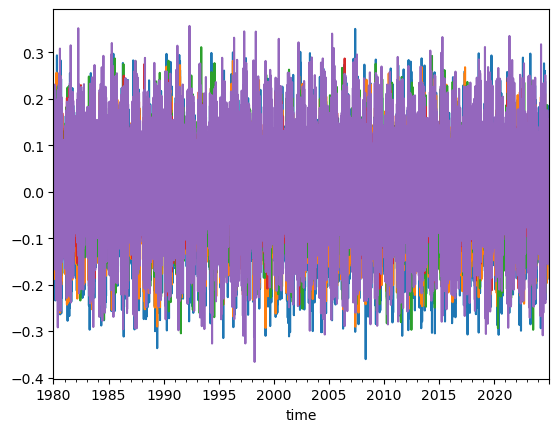

In [7]:
# Checking the Difference with mean CF
( CF_solar - PV_data["DK01"]).plot()
(CF_solar - PV_data["DK02"]).plot()
(CF_solar - PV_data["DK03"]).plot()
(CF_solar - PV_data["DK04"]).plot()
(CF_solar - PV_data["DK05"]).plot()

In [8]:
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()

print(OnshoreWind_Data.head())

                     NATIONAL      DK01      DK02      DK03      DK04  \
time                                                                    
1980-01-01 00:00:00  0.100020  0.169258  0.154797  0.058525  0.082945   
1980-01-01 01:00:00  0.095627  0.157692  0.155743  0.059855  0.076598   
1980-01-01 02:00:00  0.090815  0.145822  0.156026  0.060255  0.070185   
1980-01-01 03:00:00  0.082520  0.134984  0.153629  0.058150  0.058770   
1980-01-01 04:00:00  0.071892  0.122622  0.150896  0.054550  0.042691   

                         DK05  
time                           
1980-01-01 00:00:00  0.120442  
1980-01-01 01:00:00  0.112279  
1980-01-01 02:00:00  0.103703  
1980-01-01 03:00:00  0.092318  
1980-01-01 04:00:00  0.080078  


In [9]:
CF_wind = OnshoreWind_Data.mean(axis = 1) # average of all years for the different datasets

<Axes: xlabel='time'>

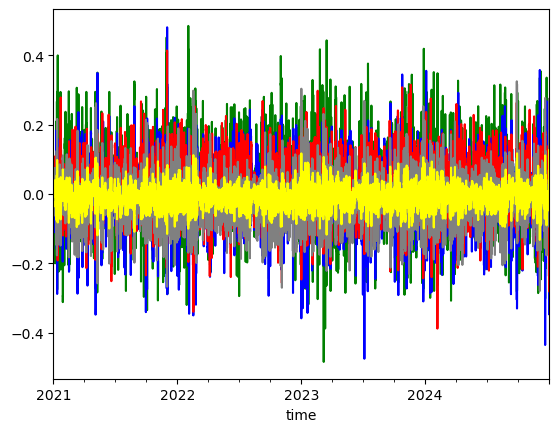

In [14]:
# Checking the Difference with mean CF
(CF_wind["2021":"2024"] - OnshoreWind_Data["DK01"]["2021":"2024"]).plot(color = "green")
(CF_wind["2021":"2024"] - OnshoreWind_Data["DK02"]["2021":"2024"]).plot(color = "blue")
(CF_wind["2021":"2024"] - OnshoreWind_Data["DK03"]["2021":"2024"]).plot(color = "red")
(CF_wind["2021":"2024"] - OnshoreWind_Data["DK04"]["2021":"2024"]).plot(color = "grey")
(CF_wind["2021":"2024"] - OnshoreWind_Data["NATIONAL"]["2021":"2024"]).plot(color = "yellow")

### Natural Gas Prices

In [15]:
current_dir = os.getcwd()
gas_file = os.path.join(current_dir, 'GasDailyBalancingPrice.xlsx')

- Pre Oct 2021, Gas Prices were constant daily from 6:00 - 6:00, per day

In [16]:
# units is in DKK/kWh
gas_price_pre_oct_2021 = pd.read_excel("GasSystemBalanceUntil20221001.xlsx")
gas_price_pre_oct_2021.tail()

,GasDay,Created,BalanceType,Balance,ProductCode,greenZoneMin,greenZoneMax,YellowZoneMin,YellowZoneMax,GasBuyingPriceDKK,GasBuyPriceDescription,GasSellingPriceDKK,GasSellPriceDescription
15861,2022-09-30 00:00:00,2022-10-01 01:45:15,ESCB,3166032,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
15862,2022-09-30 00:00:00,2022-09-30 22:45:23,ESCB,3537232,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
15863,2022-09-30 00:00:00,2022-10-31 07:28:17,SCB,9310742,Valid ordinary,-3758094,12241906,-53575500,53575500,1.2558,"Adjustment of balance purchase step 1, NG-WD *...",1.2684,"Adjustment of balance sale step 1, NG-WD * ADJ..."
15864,2022-09-30 00:00:00,2022-11-09 13:28:53,SCB,9310742,Valid ordinary,-3758094,12241906,-53575500,53575500,1.2558,"Adjustment of balance purchase step 1, NG-WD *...",1.2684,"Adjustment of balance sale step 1, NG-WD * ADJ..."
15865,2022-09-30 00:00:00,2022-09-30 06:46:05,ESCB,-4450243,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN


In [17]:
# 1. Clean and Deduplicate as you did
gas_price_pre_oct_2021["GasDay"] = pd.to_datetime(gas_price_pre_oct_2021["GasDay"]).dt.tz_localize(None)
gas_price_pre_oct_2021.index = pd.DatetimeIndex(gas_price_pre_oct_2021["GasDay"])
gas_price_pre_oct_2021 = gas_price_pre_oct_2021.groupby(level=0).mean(numeric_only=True)

# 2. Add a "dummy" row to ensure the LAST day gets all 24 hours
# This adds one more day at the very end of your existing index
last_day = gas_price_pre_oct_2021.index.max()
next_day = last_day + pd.Timedelta(days=1)
gas_price_pre_oct_2021.loc[next_day] = None 

# 3. Apply the 6-hour offset for the Danish Gas Day
gas_price_pre_oct_2021.index = gas_price_pre_oct_2021.index + pd.Timedelta(hours=6)

# 4. Resample and Forward Fill
# This propagates the 06:00 price through all 24 hours of that gas day
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021.resample('h').ffill()

# 5. Drop the very last hour (which belongs to the dummy day's 06:00 start)
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021_hourly.iloc[:-1]

Text(0, 0.5, 'Gas Price [DKK/kWh]')

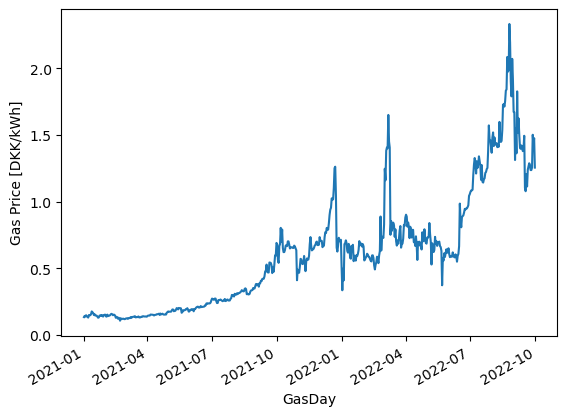

In [19]:
gas_price_pre_oct_2021["GasBuyingPriceDKK"].plot()
plt.ylabel("Gas Price [DKK/kWh]")

In [20]:
gas_price_data = pd.read_excel(gas_file)

In [21]:
# 1. Convert the 'GasDay' column to datetime and remove timezone offset
gas_price_data["GasDay"] = pd.to_datetime(gas_price_data["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data.index = pd.DatetimeIndex(gas_price_data["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
gas_price_hourly = gas_price_data.resample('h').ffill()

In [22]:
# EURO -> DKK exchange rate
EUR_DKK_exchangerate = (gas_price_hourly["ExchangeRateEUR_DKK"]/100)

Text(0, 0.5, 'Gas Price [EUR/MWh]')

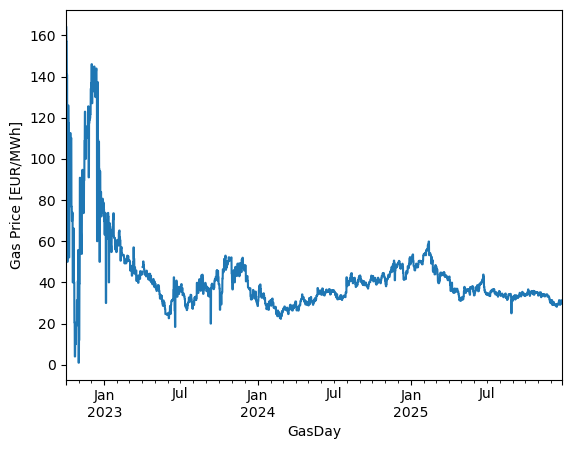

In [24]:
((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchangerate)*1000).plot() # EUR/MWh
plt.ylabel("Gas Price [EUR/MWh]")

In [25]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] = ((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchangerate)*1000)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] 

GasDay
2022-10-01 00:00:00    164.176696
2022-10-01 01:00:00    164.176696
2022-10-01 02:00:00    164.176696
2022-10-01 03:00:00    164.176696
2022-10-01 04:00:00    164.176696
                          ...    
2025-12-26 20:00:00     30.641750
2025-12-26 21:00:00     30.641750
2025-12-26 22:00:00     30.641750
2025-12-26 23:00:00     30.641750
2025-12-27 00:00:00     29.731466
Freq: h, Name: MarginalPurchasePriceEUR_MWh, Length: 28393, dtype: float64

(462336.0, 462408.0)

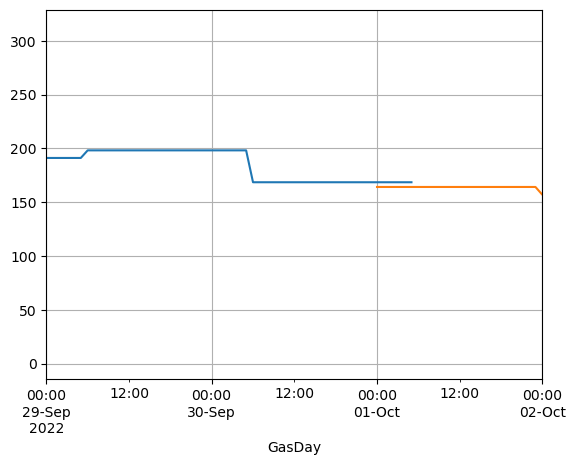

In [26]:
(gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"]*(1000/7.45)).plot()
gas_price_hourly["MarginalPurchasePriceEUR_MWh"].plot()
#elspotprices["SpotPriceEUR"].plot()
plt.grid()
plt.xlim("2022-09-29","2022-10-02")

- merging the two gas price datasets into one

In [27]:
part1 = gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"][:"2022-09-30"]*(1000/7.45)  # DKK/kwh -> EUR/MWh
part2 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"] # EUR/MWh

NG_price = pd.concat([part1, part2], axis=1)

# keep='last' prioritizes data from 'part2' for the overlapping hours
NG_price = NG_price[~NG_price.index.duplicated(keep='last')].sort_index()

# 4. Fill any remaining tiny gaps (just in case)
NG_price = NG_price.resample('H').ffill()

# 1. Fill missing values in the EUR_MWh column with the DKK column values
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].fillna(NG_price["GasBuyingPriceDKK"])

# 2. Drop the original DKK column if you no longer need it
NG_price = NG_price.drop(columns=["GasBuyingPriceDKK"])

In [28]:
gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"].isna().sum()

0

In [29]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"].isna().sum()

24

In [30]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"][gas_price_hourly["MarginalPurchasePriceEUR_MWh"].isna()]

GasDay
2023-04-01 00:00:00   NaN
2023-04-01 01:00:00   NaN
2023-04-01 02:00:00   NaN
2023-04-01 03:00:00   NaN
2023-04-01 04:00:00   NaN
2023-04-01 05:00:00   NaN
2023-04-01 06:00:00   NaN
2023-04-01 07:00:00   NaN
2023-04-01 08:00:00   NaN
2023-04-01 09:00:00   NaN
2023-04-01 10:00:00   NaN
2023-04-01 11:00:00   NaN
2023-04-01 12:00:00   NaN
2023-04-01 13:00:00   NaN
2023-04-01 14:00:00   NaN
2023-04-01 15:00:00   NaN
2023-04-01 16:00:00   NaN
2023-04-01 17:00:00   NaN
2023-04-01 18:00:00   NaN
2023-04-01 19:00:00   NaN
2023-04-01 20:00:00   NaN
2023-04-01 21:00:00   NaN
2023-04-01 22:00:00   NaN
2023-04-01 23:00:00   NaN
Freq: h, Name: MarginalPurchasePriceEUR_MWh, dtype: float64

- we were missing data for one of the days, so we will interpolate the missing data

<Axes: xlabel='GasDay'>

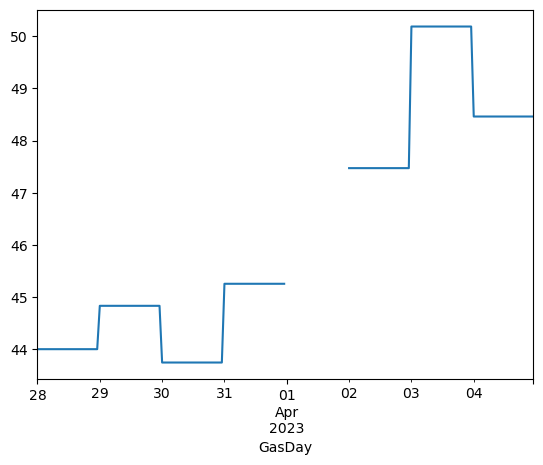

In [31]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2023-03-28":"2023-04-04"].plot()

In [33]:
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].ffill() 

<Axes: xlabel='GasDay'>

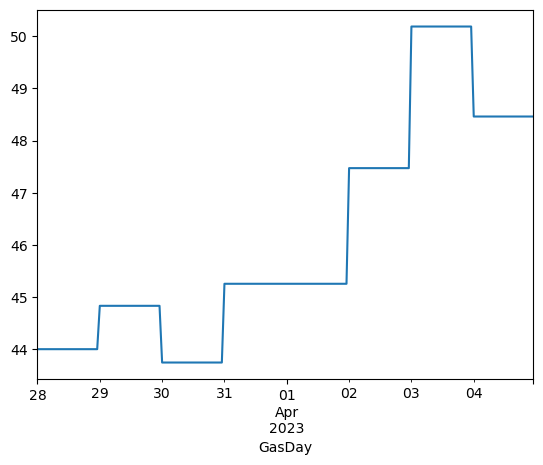

In [34]:
NG_price["MarginalPurchasePriceEUR_MWh"]["2023-03-28":"2023-04-04"].plot()

In [35]:
NG_price.isna().sum()

MarginalPurchasePriceEUR_MWh    0
dtype: int64

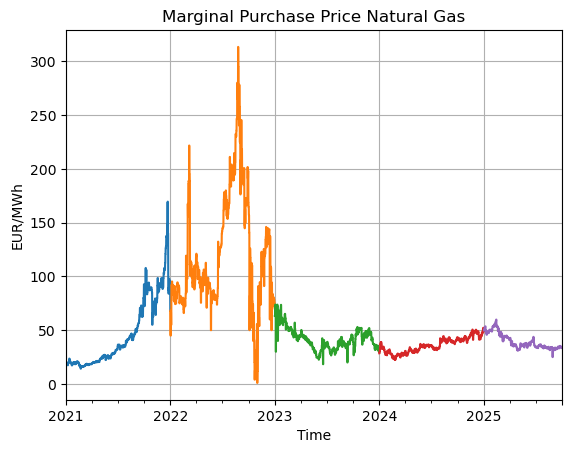

In [36]:
NG_price["MarginalPurchasePriceEUR_MWh"]["2021"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2022"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2023"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2024"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2025"].plot()
#elspotprices["SpotPriceEUR"].plot()
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.xlim("2021-01-01", "2025-09-30")
plt.title("Marginal Purchase Price Natural Gas")
plt.grid()

### Electrcity Spot Prices

In [37]:
"full spot price data el DK1";
elspotprices = pd.read_excel("Elspotprices1999_onwards.xlsx", index_col=0, parse_dates=True) # EUR/MWh

- actual costs/tariffs for every year

In [ ]:
"Historical transmission and system tariffs";
#  https://view.officeapps.live.com/op/view.aspx?src=https%3A%2F%2Fenerginet.dk%2Fmedia%2Flgomsk12%2Feltarif-arkiv-2026.xlsx&wdOrigin=BROWSELINK
"Historical Peak Load tariffs";
#  https://n1.dk/elnetkunder/tidligere-priser

In [38]:
"øre/kWh";
tariff_el_use = {
    "2021": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.123)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.09,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.92         # Net Tariff: Spidslast
    },
     "2022": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.116)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 4.51,         # Net Tariff: Lavlast
        "el_tariff_high": 8.32,        # Net Tariff: Højlast
        "el_tariff_peak": 12.15         # Net Tariff: Spidslast
    },
    "2023": {
        "el_transmission_tariff": 5.8,
        "el_system_tariff": 5.4,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.16)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.43,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.33         # Net Tariff: Spidslast
    },
    "2024": {
        "el_transmission_tariff": 7.4,
        "el_system_tariff": 5.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.24)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 0.85,         # Net Tariff: Lavlast
        "el_tariff_high": 2.54,        # Net Tariff: Højlast
        "el_tariff_peak": 5.08,         # Net Tariff: Spidslast
    }

}

In [51]:
def build_electricity_grid_price_w_tariff(Elspotprices, tariff_dict, year):
    # 1. Year Filter & Column Selection (Fixes DateParseError)
    year_str = str(year)
    spot = Elspotprices.loc[Elspotprices.index.year == int(year_str), "SpotPriceEUR"]
    
    # 2. Settings & Conversion (øre/kWh to EUR/MWh)
    d = tariff_dict[year_str]
    DKK_to_EUR_MWh = 10 / 7.45 
    
    # 3. Define Logic Windows
    hours = spot.index
    is_winter = hours.month.isin([1, 2, 3, 10, 11, 12])
    is_peak_time = hours.hour.isin(range(17, 21)) # 17:00 to 20:59
    is_day_time = hours.hour.isin(range(6, 24))   # 06:00 to 23:59

    # 4. Apply Net Tariff Levels
    net_tariff = pd.Series(d["el_tariff_low"], index=hours)
    net_tariff.loc[is_day_time] = d["el_tariff_high"]
    net_tariff.loc[is_winter & is_peak_time] = d["el_tariff_peak"]

    # 5. Calculate Final Prices
    fixed_fees = d["el_transmission_tariff"] + d["el_system_tariff"] + d["el_tax"]
    buy_price = spot + (fixed_fees + net_tariff) * DKK_to_EUR_MWh
    
    # Selling = Spot minus production costs
    sell_price = -spot + (d["el_prod_tariff"] * DKK_to_EUR_MWh)

    return buy_price, sell_price

In [ ]:
import_price21, export_price21 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2021")
import_price22, export_price22 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2022")
import_price23, export_price23 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2023")
import_price24, export_price24 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2024")

Text(0, 0.5, 'EUR/MWh')

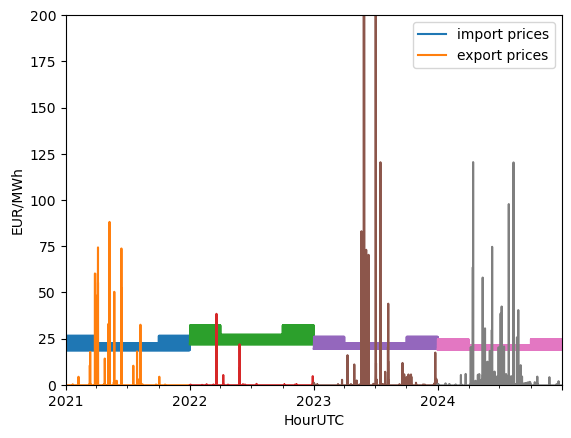

In [54]:
(import_price21 - elspotprices["SpotPriceEUR"]["2021"]).plot(label = "import prices")
(abs(export_price21) - elspotprices["SpotPriceEUR"]["2021"]).plot(label = "export prices")
plt.legend()
(import_price22 - elspotprices["SpotPriceEUR"]["2022"]).plot()
(abs(export_price22) - elspotprices["SpotPriceEUR"]["2022"]).plot()
(import_price23 - elspotprices["SpotPriceEUR"]["2023"]).plot()
(abs(export_price23) - elspotprices["SpotPriceEUR"]["2023"]).plot()
(import_price24 - elspotprices["SpotPriceEUR"]["2024"]).plot()
(abs(export_price24) - elspotprices["SpotPriceEUR"]["2024"]).plot()
plt.ylim(0,200)
plt.ylabel("EUR/MWh")

### HeatMaps

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_pypsa_heatmap(data, title="PyPSA Heatmap", unit="Value", cmap="viridis", ax=None, vmin=None, vmax=None):
    """
    Added vmin and vmax for manual scale control.
    """
    if isinstance(data, pd.DataFrame):
        plot_data = data.mean(axis=1)
    else:
        plot_data = data

    df = plot_data.to_frame(name="values")
    df["date"] = df.index.date
    df["hour"] = df.index.hour
    
    pivot = df.pivot_table(index="date", columns="hour", values="values", aggfunc='mean')

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    # Pass vmin and vmax here
    sns.heatmap(pivot, cmap=cmap, cbar_kws={'label': unit}, ax=ax, 
                rasterized=True, vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Date")

In [69]:
def get_time_period(start='2017-01-01', end='2017-12-31', freq='h', tz_naive=True):
    """
    Generates a pandas DatetimeIndex for a specified period.

    Args:
        start (str): Start date/time (e.g., '2017-01-01' or '2017-01-01 00:00Z')
        end (str): End date/time
        freq (str): Frequency (default 'h' for hourly)
        tz_naive (bool): If True, removes timezone info (localized to None)
        
    Returns:
        pd.DatetimeIndex
    """
    # Create the range
    dr = pd.date_range(start=start, end=end, freq=freq)
    
    # Strip timezone if requested
    if tz_naive and dr.tz is not None:
        dr = dr.tz_localize(None)
    elif tz_naive and dr.tz is None:
        # Even if not localized, ensure it's naive if strings had offsets
        dr = dr.tz_localize(None)
        
    return dr

In [88]:
def add_carriers(n):
    #n.add("Carrier",'electricity grid im')
    #n.add("Carrier","electricity grid ex") 
    n.add("Carrier","onshorewind")
    n.add("Carrier","solar")
    n.add("Carrier","electric boiler")
    #n.add("Carrier","Rondo charge")
    #n.add("Carrier","Rondo store")
    #n.add("Carrier","Rondo discharge")
    n.add("Carrier","heat")
    n.add("Carrier","battery storage")
    n.add("Carrier","electricity")
    n.add("Carrier","gas") # co2_emissions=0.206tonnes/MWh   # for NG boiler # Assume that methane gas emits 0.198 tCO2 per MWh of thermal energy contained in the gas. 
    n.add("Carrier", "pellets") 
    n.add("Carrier", "CO2") #co2_emissions=-0.164 (tCO2/MWh_pell) #for biochar # -0.164 ????
    n.add("Carrier", "pyrolysis")
    n.add("Carrier", "hydrogen")
    n.add("Carrier", "methanol")
    n.add("Carrier", "electrolysis")
    n.add("Carrier","digestate")

In [71]:
def add_skive_generators(n,s_cf,w_cf):

    # EuroWind Owns These Assets
    n.add("Generator", "Skive_Solar", carrier="solar",
        bus = "EuroWind" ,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu= s_cf, 
        p_nom = 36)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "EuroWind",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu= w_cf,
        p_nom = 54)

    #--------------------------------
    # PPA link
    n.add("Link", "PPA",
          bus0="EuroWind",
          bus1="Greenlab",
          p_nom_extendable=True,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity")

In [72]:
def add_grid(n, price_import, price_export):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
          bus="Grid_Import",
          p_nom_extendable=True,
          efficiency=1.0,
          marginal_cost=5e-6,
          capital_cost=0.0,
          carrier="electricity")

    n.add("Link", "Imports",
          bus0="Grid_Import",
          bus1="EuroWind",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_import)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          capital_cost=0.0,
          standing_loss=0.0,
          carrier="electricity")

    n.add("Link", "Exports",
          bus0="EuroWind",
          bus1="Grid_Export",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_export)

In [73]:
def add_battery(n,P_nom, max_t, cyclic_operation = True):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="EuroWind",  # Use your electricity bus name
        carrier="battery storage",
        max_hours= max_t,  # 22 MW * 2 h = 44 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"] + 4 * costs.at["battery storage", "capital_cost"],
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # Discharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_extendable=False,
        cyclic_state_of_charge=cyclic_operation)

In [74]:
"High Temprature Bus (350)";
def add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        e_nom= e_nom_store, # MWh
        e_nom_extendable=False,
        e_initial=0,
        e_cyclic=True,
        standing_loss= 1.2/100, # 1.2% per hour
        capital_cost=costs.at["Concrete-store", "capital_cost"] )      

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link",
        "El_to_TES_Rondo",
        bus0="Greenlab",
        bus1="TES_Rondo",
        p_nom_extendable=False,
        p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "electricity",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link",
        "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_Exchanger_Bus",
        p_nom = p_nom_discharge,
        p_nom_extendable=False,
        efficiency=0.90,
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])

In [75]:
# 2 Heat Exchanger hence effincecy = 0.9*0.9 = 0.81
def add_heat_exchanger(n):
    n.add("Link", "Heat_Exchanger_Rondo",
     bus0="Heat_Exchanger_Bus",
     bus1="Heat_MT", 
     carrier="heat", 
     p_nom_extendable=True , 
     efficiency=0.8)

In [76]:
"Medium Temprature (150 C)";
def  add_electric_boiler(n):
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "Greenlab",
        bus1="Heat_MT",
        p_nom = 10, # MW
        efficiency=0.9,
        carrier = "electric boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"])

In [77]:
# DH_Price = 40 - 60 EUR/MWh
def add_heat_load(n,p_load,DH_cost):

    n.add("Link","MT_Heat_Supply",
        bus0="Heat_MT",
        bus1="Heat_Sink",
        p_nom_extendable=True,
        carrier = "heat",
        marginal_cost = -DH_cost,) # MWh

    n.add("Load", "Skive_Heat_Load", 
        bus="Heat_Sink",
        p_nom_extendable=False,
        carrier = "heat",
        p_set = p_load) # MWh

In [78]:
def add_NG_boiler(n,CO2tax, NG_price):
     n.add("Generator",
        "NG grid",
        bus="NG",
        carrier="gas",
        p_nom = 6,
        marginal_cost = NG_price + CO2tax, #0.206  tCO2/MWh *  80EUR/tC02 + VOM 1.007EUR/MWh
        p_nom_extendable=False,)

     n.add("Link","NG boiler",
        bus0="NG",
        bus1="Heat_MT",
        efficiency=0.98,
        p_nom=6,
        p_nom_extendable=False,
        capital_cost=5772) 
    

In [ ]:
def add_SkyClean(n,CO2tax):  
    n.add("Generator",
        "pellets input",
        bus="pellets",
        carrier="pellets",
        p_nom_extendable=True,
        marginal_cost= 62) #€/MWh (Price of straw pellets 380 €/t
    
    n.add("Link",
        "pyrolysis",
        bus0="pellets",
        bus1="Heat_MT",
        bus2="Greenlab",
        bus3="biochar",
        efficiency= 3.7859/7.6748, #"biochar pyrolysis", "heat output" (MWh_th/t_CO2)/ "biochar pyrolysis", "biomass input (MWh_biomass/t_CO2), #bus1 devided by bus0.
        efficiency2= -0.3184/7.6748,   #-"biochar pyrolysis", "electricity input"] (MWh_e/t_CO2) / "biochar pyrolysis", "biomass input"(MWh_biomass/t_CO2),
        efficiency3=  1/7.6748,  #1 / "biochar pyrolysis", biochar output (waste*),
        marginal_cost= 2.5909/7.6748, #"biomass HOP", "VOM" (EUR/MWh)/ "biochar pyrolysis", "biomass input"(MWh_biomass/t_CO2)? #     
        p_nom_extendable=False,
        p_nom=2,
        carrier="pyrolysis",
        capital_cost=233477) 

    
    n.add("Link",
        "biochar sequestration",
        bus0="biochar",
        bus1="biochar sequestration",
        efficiency=1,
        p_nom_extendable = True,
        marginal_cost=-0.164*CO2tax,   #CO2 tax   or -0.164 (tCO2/MWh_pell)?  # -1  * co2_credits #-13.12eur/MWh
        carrier="CO2") 

    n.add(
        "Store",
        "biochar sequestred",
        bus="biochar sequestration",
        e_nom_extendable=True,
        e_cyclic=False,
        carrier="CO2")

In [80]:
eff_h2 = 1 / costs.at["methanolisation", "hydrogen-input"]
costs.at["methanolisation", "capital_cost"] * eff_h2

130222.11082461492

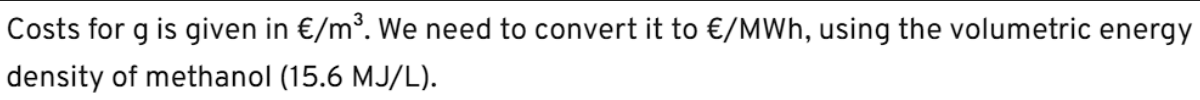

In [ ]:
"Methanolisation";
def add_methanolisation(n, p_min):
    n.add("Link",
     "methanolisation",
     bus0 = "H2_Bus",
     bus1 = "methanol_bus",
     bus2 = "Greenlab",
     bus3 = "Digestate",
     p_nom = 10, # 10 MW methanol plant
     p_min_pu = p_min,
     carrier = "methanol",
     capital_cost = costs.at["methanolisation", "capital_cost"]*eff_h2*,
     efficiency = eff_h2, # 0.87 , methanol output 
     efficiency2 = -costs.at["methanolisation", "electricity-input"]*eff_h2, # - 0.23 , electricty input
     efficiency3 = -costs.at["methanolisation", "carbondioxide-input"]*eff_h2 , # - 0.218 , Co2 input
     )

    n.add("Store",
    "methanol storage",
    bus="methanol_bus",
    carrier="methanol",
    capital_cost=costs.at["General liquid hydrocarbon storage (crude)", "capital_cost"] / (15.6 * 1000 / 3600),
    e_nom_extendable=True,
    e_cyclic=True,


In [101]:
import CoolProp.CoolProp as CP

In [99]:
costs.at["biogas","capital_cost"]

206764.5790364669

In [ ]:
def biogas_plant(n):
    # Efficency FeedStock -> Biogas = 0.46 ;
    eta_feed_biogas = 0.46
    
    n.add("Bus", "Biogas_FeedStock", carrier = "CO2")

    n.add("Bus", "Digestate", carrier = "digestate")

    n.add("Bus", "Biogas")

    n.add("Link",
    "BiogasPlant",
    bus0 = "Biogas_FeedStock", # input: Feedstock
    bus1 = "Greenlab", # input: electrcity
    bus2 = "Heat_MT", # input: heat
    bus3 = "Digestate", # output: digestate
    bus4 = "Biogas", # ouptut: Co2 (g) + CH4 } mixture
    p_nom_extendable = True,
    capital_cost = costs.at["biogas","capital_cost"],
    efficiency4 = eta_feed_biogas ,
    efficiency3 = 0.09*eta_feed_biogas, # 0.09 MW_pellets/MW_biogas
    efficiency2 = -0.103*eta_feed_biogas, # 0.103 MW_th/MW_biogas
    efficiency = -0.04*eta_feed_biogas, #  0.04 MW_el/MW_biogas
    )

    n.add("Link",
    "Digestate_to_Pellets",
    bus0 = "Digestate",
    bus1 = "pellets",
    p_nom_extendable = True,
    efficency)

In [82]:
def add_MeOH_load(n, P_MeOH):
    n.add("Load",
    "MeOH Demand",
    bus = "methanol_bus",
    carrier = "methanol",
    p_set = P_MeOH)

In [83]:
"Adding Electrolyser"
def add_electrolyser(n, P_elec):
    n.add("Link",
    "Electrolyser",
    bus0 = "Greenlab",
    bus1 = "H2_Bus",
    p_nom = P_elec,
    p_nom_extendable = True,
    carrier = "electrolysis",
    p_min_pu = 0.15,
    #p_nom_min = , 
    #p_nom_max = ,
    capital_cost = costs.at["Alkaline electrolyzer medium size", "capital_cost"],
    marginal_cost = costs.at["Alkaline electrolyzer medium size", "marginal_cost"],
    efficiency = 0.6,)

    n.add("Store",
    "H2_Storage",
    bus = "H2_Bus",
    e_nom_extendable = True,
    carrier = "hydrogen",
    e_cylic = True)

In [84]:
def add_H2_demand(n,P_H2):
    n.add("Load",
    "H2 Demand",
    bus = "H2_Bus",
    carrier = "hydrogen",
    p_set = P_H2)

In [85]:
#Fixed demand
def add_el_load(n,p_el):
    "Adding the Localised Demand in Greenlab Skive";
    n.add("Load",  "Skive_el_Load", 
        bus="Greenlab", 
        p_set= p_el,
        carrier = "electricity") #MWh

In [86]:
def build_network2(P_H2,P_MeOH,p_min,P_el,P_heat,CO2_tax1, CO2_tax2,p_import,p_export,NG_price,horizon):
     
    n = pypsa.Network()
    #hours = get_time_period('2023-01-01 00:00Z', '2023-12-31 23:00Z', freq = "h")
    #n.set_snapshots(hours)½
    n.set_snapshots(NG_price.index)


    # Use .loc[n.snapshots] to ensure data perfectly matches the network's time index
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_import = p_import.loc[n.snapshots].values
    p_export = p_export.loc[n.snapshots].values

    add_carriers(n)

    n.add("Bus", "Greenlab", carrier = "electricity")
    n.add("Bus", "EuroWind", carrier = "electricity")
    n.add("Bus", "Grid_Import", carrier = "electricity")
    n.add("Bus", "Grid_Export", carrier = "electricity")
    
    n.add("Bus", "H2_Bus", carrier = "hydrogen")

    n.add("Bus", "Heat_Exchanger_Bus", carrier = "heat")
    n.add("Bus","TES_Rondo", carrier = "heat")
    n.add("Bus", "Heat_MT", carrier = "heat")
    n.add("Bus","Heat_Sink", carrier = "heat")

    n.add("Bus", "NG", carrier = "gas")
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "biochar", carrier="CO2")
    n.add("Bus", "biochar sequestration", carrier="CO2")

    n.add("Bus", "methanol_bus", carrier="methanol")


    add_battery(n,P_nom = 22, max_t = 2, cyclic_operation = True)
    add_skive_generators(n,s_cf,w_cf) # 90 EUR/MWh
    add_grid(n,p_import,p_export)

    add_el_load(n,P_el)
    add_heat_load(n,P_heat,DH_cost = 0) # 50 EUR/MWh

    add_electrolyser(n, P_elec = 12)
    add_methanolisation(n,p_min) # {0.87} H2 comes from H2_Bus


    add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7)
    add_heat_exchanger(n)
    add_electric_boiler(n)
    add_NG_boiler(n,CO2_tax1,NG_price)
    add_SkyClean(n,CO2_tax2)

    add_MeOH_load(n, P_MeOH = 1)
    add_H2_demand(n,P_H2 = 2)


    #print(n.consistency_check())
    # 3. Optimize and return the actual network object 'n'
    # SOLVING
    if horizon is not None:
        # Solving in chunks (useful for large datasets or limited memory)
        n.optimize.optimize_with_rolling_horizon(solver_name="gurobi", horizon=horizon)
    else:
        # Solving the full year at once
        n.optimize(solver_name="gurobi")

    return n

In [87]:
n21 = build_network2(P_H2 = 2,P_MeOH = 1,p_min = 0.1,P_el = 2,P_heat = 5,CO2_tax1 = 80, CO2_tax2 = 80,p_import = import_price21 ,p_export = export_price21,NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2021"] ,horizon= None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:01<00:00, 10.53it/s]
INFO:linopy.io: Writing time: 6.33s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 9845 iterations and 23.82 seconds (4.68 work units)


INFO:gurobipy:Solved in 9845 iterations and 23.82 seconds (4.68 work units)


Optimal objective -3.291412204e+06


INFO:gurobipy:Optimal objective -3.291412204e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 271386 primals, 630299 duals
Objective: -3.29e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.
